In [1]:
import os
import sys
# module_path = os.path.abspath(os.path.join('..'))
# if module_path not in sys.path:
#     sys.path.append(module_path)
# os.chdir('..')

In [2]:
import os
import pandas as pd
import numpy as np
# from composition_vectorizer.featurizers import featurizer_1d
# from modules.functions import get_elem_count
from sklearn.preprocessing import StandardScaler
import torch
from sparsenn import MultiTaskMSELoss
import sparsenn
from sparsenn import pareto
import torch.nn as nn
import torch.optim as optim
import copy
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
# import pymatgen.core as mg
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import KFold

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
# from skl2onnx import to_onnx
# from modules.trainers import base_trainer, wPCGrad_DTP_trainer
# from modules.mt_tools import wPCGrad, DynamicTaskPrioritization

In [10]:
data_name = 'yang_dataset'

results_saveloc = os.path.join('l0_results',data_name)
models_saveloc = os.path.join('l0_saved_models',data_name)

if not os.path.exists(results_saveloc):
    os.makedirs(results_saveloc)

if not os.path.exists(models_saveloc):
    os.makedirs(models_saveloc)

In [3]:
def insert_missing_values(y_original, main_task, task_list, mode = 'extrapolation', f_missing = 0.5):
    rng = np.random.default_rng(0)
    missing = y_original.copy()
    miss_idx = []
    for col in main_task:
        i = np.argwhere(np.array(task_list) == col).item()
        if mode == 'extrapolation':
            pct_missing = 100 * f_missing
            lo, hi = np.percentile(missing[:,i], [pct_missing/2, 100-pct_missing/2])
            rand_idx = np.argwhere((missing[:,i] < lo) | (missing[:,i] > hi)).flatten()
        elif mode == 'interpolation':
            pct_missing = 100 * f_missing
            lo, hi = np.percentile(missing[:,i], 0.5*np.array([100-pct_missing, 100+pct_missing]))
            rand_idx = np.argwhere((missing[:,i] > lo) & (missing[:,i] < hi)).flatten()
        elif mode == 'random':
            n_missing = int(f_missing * missing.shape[0])
            rand_idx = rng.choice(np.arange(missing.shape[0]), n_missing, replace=False)
            lo, hi = None, None
        else:
            raise ValueError('Mode must be one of {extrapolate, interpolate, random}')
        
        missing[rand_idx, i] = np.nan
        miss_idx.append(rand_idx)
    
    return missing, miss_idx, lo, hi

# Load dataset

In [4]:
np.random.seed(0)

# yang_dataset = pd.read_csv('../ST_MT_DATASETS/hardness_yang2022+dft_full.csv', index_col = 0)
yang_dataset = pd.read_csv('../../multi_task_learning/dataset/hardness_yang2022+dft_full.csv', index_col=0)
comps = yang_dataset['Composition'].values
# to_remove = set(['Ti','Mo','Mn','V'])
# to_keep_inds = [i for i,x in enumerate(comps) if len(set(mg.Composition(x).get_el_amt_dict().keys()).intersection(to_remove)) == 0]

to_keep_dataset = yang_dataset.copy() #yang_dataset.iloc[to_keep_inds].copy()
to_keep_dataset.reset_index(inplace=True,drop=True)
compositions = to_keep_dataset['Composition'].values

# elems = get_elem_count(compositions).keys()
# comp_vec, order = featurizer_1d(compositions.tolist(),'alphabet',elems)

In [5]:
### FROM WES ###

import re

def parse_alloy_composition(composition):
    # Regular expression to match elements and their amounts
    pattern = re.compile(r'([A-Z][a-z]*)(\d*\.?\d*)')
    matches = pattern.findall(composition)
    
    # Create a dictionary to store elements and their amounts
    elements = {}
    for element, amount in matches:
        if amount == '':
            amount = 1.0  # Default amount is 1 if not specified
        else:
            amount = float(amount)
        elements[element] = amount
    
    return elements


ele_dict = [parse_alloy_composition(it) for it in comps]
ele_occurence = {}
for c in ele_dict:
    for k in c.keys():
        if k not in ele_occurence:
            ele_occurence[k] = 0
        ele_occurence[k] += 1


ele_lookup = {k: i for i, k in enumerate(sorted(ele_occurence.keys()))}
ele_arr = np.zeros([len(yang_dataset), len(ele_occurence)], dtype=float)
for idx, comp in enumerate(ele_dict):
    for ele, frac in comp.items():
        ele_arr[idx, ele_lookup[ele]] = frac
ele_arr /= ele_arr.sum(axis=1).reshape(-1, 1)
print(np.percentile(np.sum(ele_arr, axis=1), [0, 100]))
df_comp = pd.DataFrame(ele_arr, columns=ele_lookup.keys())
order = df_comp.columns

[1. 1.]


In [6]:
main_task = ['HV']
rem_tasks = list(set(yang_dataset.columns[1:].tolist())-set(main_task))

hv = yang_dataset.loc[:,main_task].values.reshape(-1,1)
dft = yang_dataset.loc[:,rem_tasks].values


dict_dft = {}
for i,dft_name in enumerate(rem_tasks):
    mutual_info_xy = mutual_info_regression(dft[:,i].reshape(-1,1), hv.ravel()).item()
    mutual_info_xx = mutual_info_regression(hv,hv.ravel()).item()
    mutual_info_yy = mutual_info_regression(dft[:,i].reshape(-1,1),dft[:,i]).item()
    dict_dft[dft_name] = mutual_info_xy/((mutual_info_xx+mutual_info_yy)/2)

mi_dict = {x:y for x, y in sorted(dict_dft.items(), key=lambda item: item[1], reverse=True)}
top_five_feats = list(mi_dict.keys())[:3]

task_list = main_task + top_five_feats #to_keep_dataset.columns[1:]
unscaled_y = to_keep_dataset.loc[:,task_list].values
scalers_dict = {x:StandardScaler().fit(unscaled_y[:,i].reshape(-1,1)) for i,x in enumerate(task_list)}
y_original = [scalers_dict[x].transform(unscaled_y[:,i].reshape(-1,1)).flatten() for i,x in enumerate(task_list)]
y_original = np.array(y_original).T.astype('float32')


comp_vec = torch.Tensor(df_comp.values.astype('float32'))
y = torch.Tensor(y_original.copy())

# 5-fold cross validation

In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=0)
train_test_dict = {}
for i,(train,test) in enumerate(kf.split(comp_vec)):
    train_test_dict[i] = {'train':train,'test':test}

mode = '5_fold'
# if not os.path.exists(os.path.join(models_saveloc,mode)):
#     os.makedirs(os.path.join(models_saveloc,mode))

## RF

Text(0.05, 0.95, '$R^2 = 0.872\\pm0.023$')

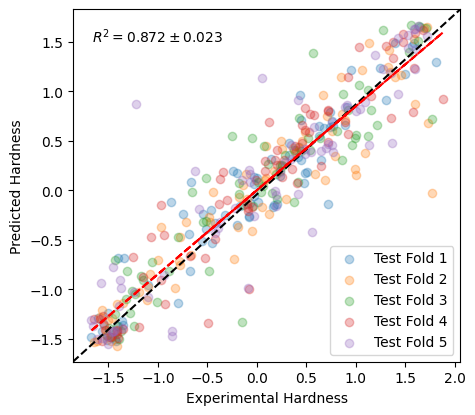

In [10]:
to_plot = {'true':[],'predicted':[]}

for i in train_test_dict.keys():
    train,test = train_test_dict[i]['train'], train_test_dict[i]['test']
    X_train, X_test = comp_vec[train], comp_vec[test]
    y_train, y_test = y_original[train,0], y_original[test,0]
    rf = RandomForestRegressor(random_state=0)

    rf.fit(X_train, y_train)
    # onx = to_onnx(rf, X_train[:1].numpy().astype(np.float32), target_opset=12)
    # with open(os.path.join(models_saveloc,mode,f'RF_Fold_{i}.onnx'), "wb") as f:
    #     f.write(onx.SerializeToString())

    predicted = rf.predict(X_test)
    to_plot['true'].append(y_test)
    to_plot['predicted'].append(predicted)

fig,ax = plt.subplots(figsize = (5,5))
r2_scores, rmse_scores = [],[]
for i in range(len(train_test_dict.keys())):
    ax.scatter(to_plot['true'][i],to_plot['predicted'][i], label = f'Test Fold {i+1}', alpha = 0.3)
    r2_scores.append(r2_score(to_plot['true'][i],to_plot['predicted'][i]))
    rmse_scores.append(np.sqrt(mean_squared_error(to_plot['true'][i],to_plot['predicted'][i])))

ax.set_xlabel('Experimental Hardness')
ax.set_ylabel('Predicted Hardness')

all_true = [x for xs in to_plot['true'] for x in xs]
all_predicted = [x for xs in to_plot['predicted'] for x in xs]
ax.plot([0, 1], [0, 1], transform=ax.transAxes, linestyle='--', color = 'k')

z = np.polyfit(all_true, all_predicted, 1)
p = np.poly1d(z)
ax.plot(all_true,p(all_true),"r--")
plt.legend()
plt.gca().set_aspect('equal')
ax.text(0.05, 0.95, f'$R^2 = {np.mean(r2_scores):.3f}\pm{np.std(r2_scores):.3f}$', transform=ax.transAxes, ha='left', va='top')


## STL0

<>:53: SyntaxWarning: invalid escape sequence '\p'
<>:53: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3982599/1574608675.py:53: SyntaxWarning: invalid escape sequence '\p'
  ax.text(0.05, 0.95, f'$R^2 = {np.mean(r2_scores):.3f}\pm{np.std(r2_scores):.3f}$', transform=ax.transAxes, ha='left', va='top')


Epoch 1000, MSE: 0.3605, L0R: 1087.79
Epoch 2000, MSE: 0.1802, L0R: 954.17
Epoch 3000, MSE: 0.1617, L0R: 872.11
Epoch 4000, MSE: 0.1385, L0R: 832.51
Epoch 5000, MSE: 0.1507, L0R: 812.80
Epoch 6000, MSE: 0.1521, L0R: 802.53
Epoch 7000, MSE: 0.1324, L0R: 797.38
Epoch 8000, MSE: 0.1348, L0R: 794.89
Epoch 9000, MSE: 0.1920, L0R: 794.04
Epoch 10000, MSE: 0.2766, L0R: 793.85
Epoch 11000, MSE: 0.1263, L0R: 793.84
Epoch 12000, MSE: 0.1167, L0R: 794.36
Epoch 13000, MSE: 0.1068, L0R: 794.65
Epoch 14000, MSE: 0.1037, L0R: 795.35
Epoch 15000, MSE: 0.0828, L0R: 796.06
Epoch 16000, MSE: 0.0919, L0R: 796.67
Epoch 17000, MSE: 0.0784, L0R: 797.35
Epoch 18000, MSE: 0.0985, L0R: 797.98
Epoch 19000, MSE: 0.0890, L0R: 798.40
Patience expired...
Epoch 1000, MSE: 0.3812, L0R: 1088.78
Epoch 2000, MSE: 0.2801, L0R: 962.35
Epoch 3000, MSE: 0.1400, L0R: 879.77
Epoch 4000, MSE: 0.2118, L0R: 836.97
Epoch 5000, MSE: 0.1529, L0R: 814.33
Epoch 6000, MSE: 0.2625, L0R: 802.04
Epoch 7000, MSE: 0.1584, L0R: 795.55
Epoch 

Text(0.05, 0.95, '$R^2 = 0.851\\pm0.042$')

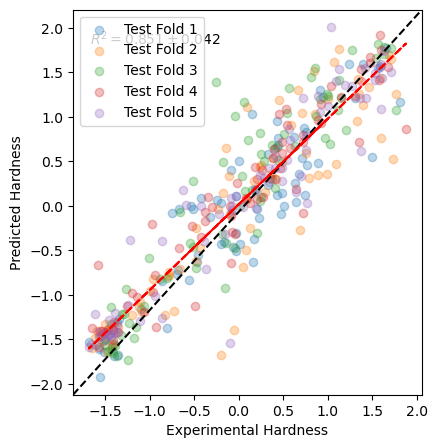

In [143]:
to_plot = {'true':[],'predicted':[]}
torch.manual_seed(0)
for i in train_test_dict.keys():
    train,test = train_test_dict[i]['train'], train_test_dict[i]['test']
    X_train, X_test = comp_vec[train], comp_vec[test]
    y_train, y_test = y_original[train,0].reshape(-1,1), y_original[test,0].reshape(-1,1)
    input_dim = X_train.shape[1]
    hidden_dim = (16,16,16,16)
    output_dim = 1

    X_train = torch.Tensor(X_train)
    y_train = torch.Tensor(y_train)

    model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = MultiTaskMSELoss()
    trainer = base_trainer(model, optimizer)
    lite_model, best_model_wts = trainer(X_train, y_train, criterion)

    torch.save(best_model_wts,os.path.join(os.path.join(models_saveloc,mode,f'STL0_Fold_{i}.pt')))
    
    st_model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim)
    st_model.load_state_dict(best_model_wts)
    # best_model = lite_model
    st_model.eval()
    with torch.no_grad():
        predicted = st_model(torch.Tensor(X_test))
    to_plot['true'].append(y_test)
    to_plot['predicted'].append(predicted.numpy())
    
    
fig,ax = plt.subplots(figsize = (5,5))
r2_scores, rmse_scores = [],[]
for i in range(len(train_test_dict.keys())):
    ax.scatter(to_plot['true'][i],to_plot['predicted'][i], label = f'Test Fold {i+1}', alpha = 0.3)
    r2_scores.append(r2_score(to_plot['true'][i],to_plot['predicted'][i]))
    rmse_scores.append(np.sqrt(mean_squared_error(to_plot['true'][i],to_plot['predicted'][i])))

ax.set_xlabel('Experimental Hardness')
ax.set_ylabel('Predicted Hardness')

all_true = [x for xs in to_plot['true'] for x in xs]
all_predicted = [x for xs in to_plot['predicted'] for x in xs]
all_true = np.array(all_true).flatten()
all_predicted = np.array(all_predicted).flatten()
ax.plot([0, 1], [0, 1], transform=ax.transAxes, linestyle='--', color = 'k')

z = np.polyfit(all_true, all_predicted, 1)
p = np.poly1d(z)
ax.plot(all_true,p(all_true),"r--")
plt.legend()
plt.gca().set_aspect('equal')
ax.text(0.05, 0.95, f'$R^2 = {np.mean(r2_scores):.3f}\pm{np.std(r2_scores):.3f}$', transform=ax.transAxes, ha='left', va='top')

# Missing at Random

Text(0, 0.5, 'Values')

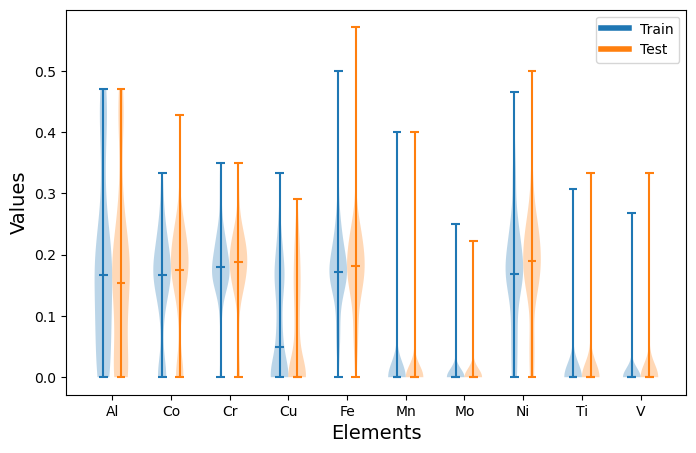

In [164]:
mode = 'random'
if not os.path.exists(os.path.join(models_saveloc,mode)):
    os.makedirs(os.path.join(models_saveloc,mode))

missing, miss_idx, lo, hi = insert_missing_values(y_original, main_task, task_list, mode = mode)

X_train = comp_vec
y_train = missing
X_test = comp_vec[miss_idx[0]]
y_test = y_original[miss_idx[0]]

test_comps = X_train[~np.isfinite(y_train[:,0])]
train_comps = X_train[np.isfinite(y_train[:,0])]

fig,ax = plt.subplots(figsize = (8,5))

x_plot_train = np.arange(train_comps.shape[1])
x_plot_test = x_plot_train+0.3
ax.violinplot(train_comps.numpy(), positions = x_plot_train, widths=0.3,showmeans=False, showmedians=True)
ax.violinplot(test_comps.numpy(), positions = x_plot_test, widths= 0.3, showmeans=False, showmedians=True)
ax.set_xticks(x_plot_train + 0.15, order)

train_artist = plt.Line2D([0], [0], color='tab:blue', lw=4, label='Train')
test_artist = plt.Line2D([0], [0], color='tab:orange', lw=4, label='Test')

# Add legend
ax.legend(handles=[train_artist, test_artist])
# Add labels and title

ax.set_xlabel('Elements', fontsize = 14)
ax.set_ylabel('Values', fontsize = 14)

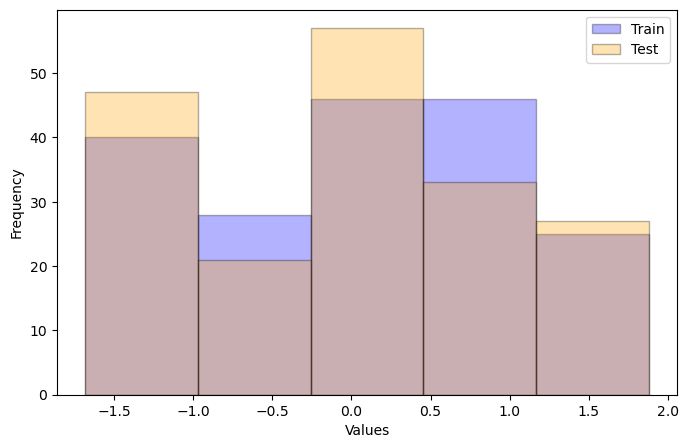

In [165]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming y_train and y_test are defined:
# y_train, y_test

# Determine the range of the data to ensure consistent binning
data_min = min(np.nanmin(y_train[:, 0]), np.nanmin(y_test[:, 0]))
data_max = max(np.nanmax(y_train[:, 0]), np.nanmax(y_test[:, 0]))

# Create common bin edges
bins = np.linspace(data_min, data_max, 6)  # 5 bins means 6 edges

# Plot histograms with the same bins
plt.figure(figsize=(8, 5))
plt.hist(y_train[:, 0], alpha = 0.3, bins=bins, label='Train', color='blue', edgecolor='black')
plt.hist(y_test[:, 0], alpha = 0.3, bins=bins, label='Test', color='orange', edgecolor='black')

# Add labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
# Add legend
plt.legend()

# Show plot
plt.show()

## RF

(-2.0, 2.0)

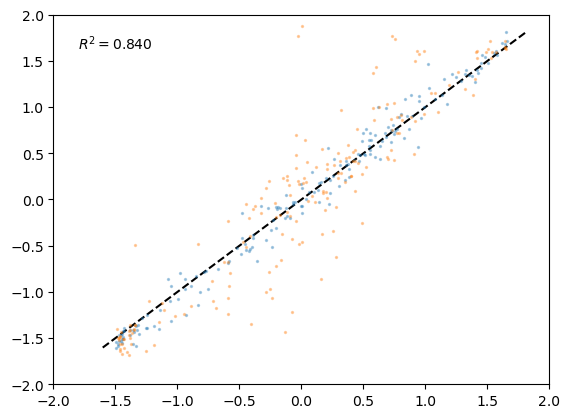

In [109]:
rf = RandomForestRegressor(random_state = 0)
is_finite = np.isfinite(y_train[:, 0])
_ = rf.fit(X_train[is_finite].numpy(), y_train[is_finite, 0])

onx = to_onnx(rf, X_train[:1].numpy().astype(np.float32), target_opset=12)
with open(os.path.join(models_saveloc,mode,'RF.onnx'), "wb") as f:
    f.write(onx.SerializeToString())

out_train = rf.predict(X_train)
out_test = rf.predict(X_test)

fig,ax = plt.subplots()
min_max = [op(y_train[:, 0]) for op in (np.nanmin, np.nanmax)]
ax.plot(min_max, min_max, 'k--', zorder=0)

is_finite = np.isfinite(y_test[:, 0])
r2_test = r2_score(y_test[:, 0], out_test)
ax.scatter(out_train, y_train[:, 0], s=2, alpha=0.33)
ax.scatter(out_test, y_test[:, 0], s=2, alpha=0.33)
ax.text(0.05, 0.95, f'$R^2 = {r2_test:.3f}$', transform=ax.transAxes, ha='left', va='top')
# ax.set_ylim(y_test[:,0].min(),y_test[:,0].max())
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2) 

## STL0

Epoch 1000, MSE: 0.1666, L0R: 786.70
Epoch 2000, MSE: 0.1822, L0R: 700.07
Epoch 3000, MSE: 0.1589, L0R: 646.60
Epoch 4000, MSE: 0.1687, L0R: 620.67
Epoch 5000, MSE: 0.1719, L0R: 608.42
Epoch 6000, MSE: 0.2154, L0R: 602.48
Epoch 7000, MSE: 0.1151, L0R: 599.59
Epoch 8000, MSE: 0.1644, L0R: 598.55
Epoch 9000, MSE: 0.1038, L0R: 598.42
Epoch 10000, MSE: 0.1156, L0R: 599.02
Epoch 11000, MSE: 0.0896, L0R: 599.68
Epoch 12000, MSE: 0.0917, L0R: 600.48
Epoch 13000, MSE: 0.1639, L0R: 601.41
Epoch 14000, MSE: 0.0964, L0R: 602.30
Epoch 15000, MSE: 0.0880, L0R: 603.22
Epoch 16000, MSE: 0.0989, L0R: 604.02
Epoch 17000, MSE: 0.0950, L0R: 604.91
Epoch 18000, MSE: 0.0892, L0R: 605.56
Epoch 19000, MSE: 0.1194, L0R: 606.07
Epoch 20000, MSE: 0.0617, L0R: 606.29
Epoch 21000, MSE: 0.0616, L0R: 606.34
Epoch 22000, MSE: 0.0516, L0R: 606.24
Epoch 23000, MSE: 0.0549, L0R: 606.02
Epoch 24000, MSE: 0.0756, L0R: 605.62
Epoch 25000, MSE: 0.0535, L0R: 605.45
Epoch 26000, MSE: 0.0436, L0R: 605.25
Epoch 27000, MSE: 0.0

(-2.0, 2.0)

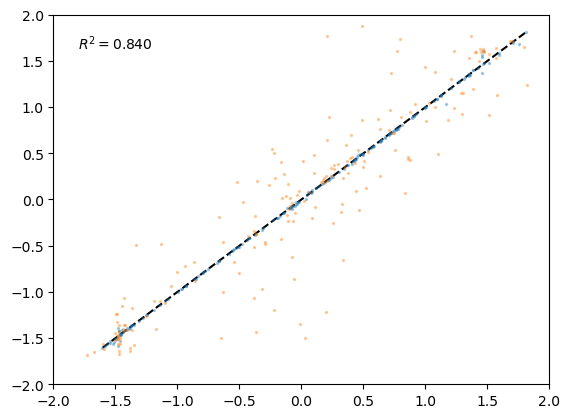

In [106]:
torch.manual_seed(0)
input_dim = X_train.shape[1]
hidden_dim = (16,16,16)
output_dim = 1

X_train = torch.Tensor(X_train)
y_train_st = torch.Tensor(y_train[:,0].reshape(-1,1))
model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = MultiTaskMSELoss()
trainer = base_trainer(model, optimizer)
lite_model, best_model_wts = trainer(X_train, y_train_st, criterion)

torch.save(best_model_wts,os.path.join(os.path.join(models_saveloc,mode,'STL0.pt')))

st_model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim)
st_model.load_state_dict(best_model_wts)
# best_model = lite_model
st_model.eval()
with torch.no_grad():
        out_test = st_model(torch.Tensor(X_test))
        out_train = st_model(torch.Tensor(X_train))


fig,ax = plt.subplots()
min_max = [op(y_train[:, 0]) for op in (np.nanmin, np.nanmax)]
ax.plot(min_max, min_max, 'k--', zorder=0)

is_finite = np.isfinite(y_test[:, 0])
r2_test = r2_score(y_test[:, 0], out_test)
ax.scatter(out_train, y_train[:, 0], s=2, alpha=0.33)
ax.scatter(out_test, y_test[:, 0], s=2, alpha=0.33)
ax.text(0.05, 0.95, f'$R^2 = {r2_test:.3f}$', transform=ax.transAxes, ha='left', va='top')
# ax.set_ylim(y_test[:,0].min(),y_test[:,0].max())
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2) 

## MTL0

Epoch 1000, MSE: 0.1958, L0R: 868.90
Epoch 2000, MSE: 0.1584, L0R: 800.71
Epoch 3000, MSE: 0.1434, L0R: 757.50
Epoch 4000, MSE: 0.1448, L0R: 735.57
Epoch 5000, MSE: 0.1682, L0R: 722.39
Epoch 6000, MSE: 0.1564, L0R: 714.39
Epoch 7000, MSE: 0.1501, L0R: 710.95
Epoch 8000, MSE: 0.1509, L0R: 709.61
Epoch 9000, MSE: 0.1443, L0R: 709.57
Epoch 10000, MSE: 0.1380, L0R: 710.01
Epoch 11000, MSE: 0.1333, L0R: 710.82
Epoch 12000, MSE: 0.1165, L0R: 711.49
Epoch 13000, MSE: 0.1291, L0R: 712.28
Epoch 14000, MSE: 0.1180, L0R: 712.94
Epoch 15000, MSE: 0.1098, L0R: 713.54
Epoch 16000, MSE: 0.1059, L0R: 713.99
Epoch 17000, MSE: 0.0990, L0R: 714.46
Epoch 18000, MSE: 0.0917, L0R: 714.51
Epoch 19000, MSE: 0.0942, L0R: 714.58
Epoch 20000, MSE: 0.0821, L0R: 714.78
Epoch 21000, MSE: 0.0800, L0R: 714.71
Epoch 22000, MSE: 0.0814, L0R: 714.60
Epoch 23000, MSE: 0.0734, L0R: 714.49
Epoch 24000, MSE: 0.0682, L0R: 714.42
Epoch 25000, MSE: 0.0619, L0R: 714.20
Epoch 26000, MSE: 0.0591, L0R: 713.65
Epoch 27000, MSE: 0.0

(-2.0, 2.0)

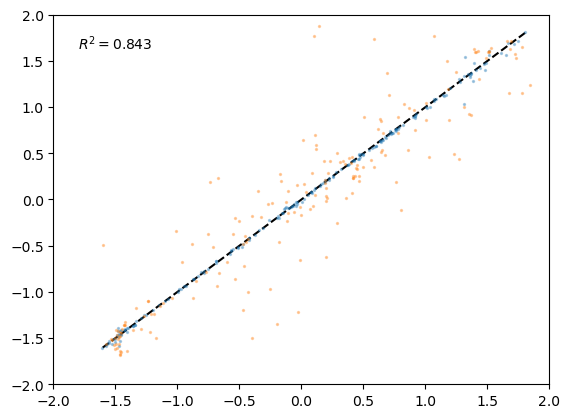

In [113]:
torch.manual_seed(0)
input_dim = X_train.shape[1]
hidden_dim = (16,16,16)
output_dim = y_train.shape[1]
criterion = MultiTaskMSELoss()

y_train_mt = torch.Tensor(y_train)
model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
pcgrad_mtl = wPCGrad(model, output_dim, optimizer, criterion, lambda_reg=1e-5)
dtp = DynamicTaskPrioritization(output_dim, gamma=2)
task_priority = [0]

trainer = wPCGrad_DTP_trainer(pcgrad_mtl, dtp, task_priority)
lite_model, best_model_wts = trainer(X_train, y_train_mt, criterion, patience_interval = 1500)
torch.save(best_model_wts,os.path.join(os.path.join(models_saveloc,mode,'MTL0.pt')))

mt_model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim)
mt_model.load_state_dict(best_model_wts)
# best_model = lite_model
mt_model.eval()
with torch.no_grad():
    out_test = mt_model(torch.Tensor(X_test))
    out_train = mt_model(torch.Tensor(X_train))


fig,ax = plt.subplots()
min_max = [op(y_train[:, 0]) for op in (np.nanmin, np.nanmax)]
ax.plot(min_max, min_max, 'k--', zorder=0)

is_finite = np.isfinite(y_test[:, 0])
r2_test = r2_score(y_test[:, 0], out_test[:,0])
ax.scatter(out_train[:,0], y_train[:, 0], s=2, alpha=0.33)
ax.scatter(out_test[:,0], y_test[:, 0], s=2, alpha=0.33)
ax.text(0.05, 0.95, f'$R^2 = {r2_test:.3f}$', transform=ax.transAxes, ha='left', va='top')
# ax.set_ylim(y_test[:,0].min(),y_test[:,0].max())
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2) 

# Extrapolation

Text(0, 0.5, 'Values')

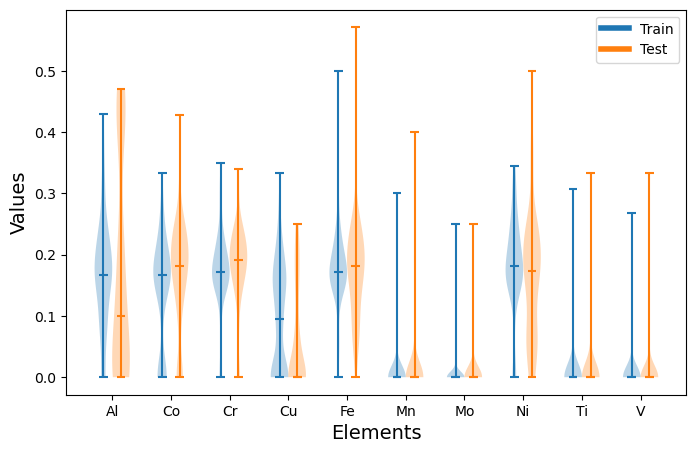

In [146]:
mode = 'extrapolation'
if not os.path.exists(os.path.join(models_saveloc,mode)):
    os.makedirs(os.path.join(models_saveloc,mode))

missing, miss_idx, lo, hi = insert_missing_values(y_original, main_task, task_list, mode = mode)

X_train = comp_vec
y_train = missing
X_test = comp_vec[miss_idx[0]]
y_test = y_original[miss_idx[0]]

test_comps = X_train[~np.isfinite(y_train[:,0])]
train_comps = X_train[np.isfinite(y_train[:,0])]

fig,ax = plt.subplots(figsize = (8,5))

x_plot_train = np.arange(train_comps.shape[1])
x_plot_test = x_plot_train+0.3
ax.violinplot(train_comps.numpy(), positions = x_plot_train, widths=0.3,showmeans=False, showmedians=True)
ax.violinplot(test_comps.numpy(), positions = x_plot_test, widths= 0.3, showmeans=False, showmedians=True)
ax.set_xticks(x_plot_train + 0.15, order)

train_artist = plt.Line2D([0], [0], color='tab:blue', lw=4, label='Train')
test_artist = plt.Line2D([0], [0], color='tab:orange', lw=4, label='Test')

# Add legend
ax.legend(handles=[train_artist, test_artist])
# Add labels and title

ax.set_xlabel('Elements', fontsize = 14)
ax.set_ylabel('Values', fontsize = 14)

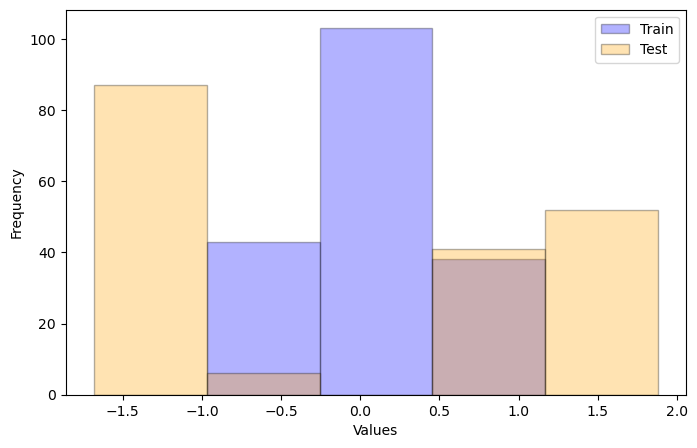

In [163]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming y_train and y_test are defined:
# y_train, y_test

# Determine the range of the data to ensure consistent binning
data_min = min(np.nanmin(y_train[:, 0]), np.nanmin(y_test[:, 0]))
data_max = max(np.nanmax(y_train[:, 0]), np.nanmax(y_test[:, 0]))

# Create common bin edges
bins = np.linspace(data_min, data_max, 6)  # 5 bins means 6 edges

# Plot histograms with the same bins
plt.figure(figsize=(8, 5))
plt.hist(y_train[:, 0], alpha = 0.3, bins=bins, label='Train', color='blue', edgecolor='black')
plt.hist(y_test[:, 0], alpha = 0.3, bins=bins, label='Test', color='orange', edgecolor='black')

# Add labels and title
plt.xlabel('Values')
plt.ylabel('Frequency')
# Add legend
plt.legend()

# Show plot
plt.show()


### RF

(-2.0, 2.0)

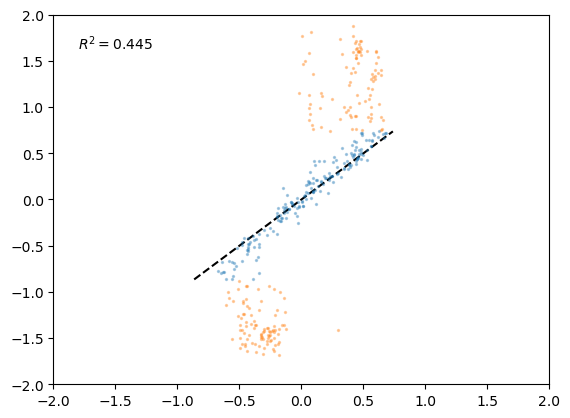

In [24]:
rf = RandomForestRegressor(random_state = 0)
is_finite = np.isfinite(y_train[:, 0])
_ = rf.fit(X_train[is_finite].numpy(), y_train[is_finite, 0])

onx = to_onnx(rf, X_train[:1].numpy().astype(np.float32), target_opset=12)
with open(os.path.join(models_saveloc,mode,'RF.onnx'), "wb") as f:
    f.write(onx.SerializeToString())

out_train = rf.predict(X_train)
out_test = rf.predict(X_test)

fig,ax = plt.subplots()
min_max = [op(y_train[:, 0]) for op in (np.nanmin, np.nanmax)]
ax.plot(min_max, min_max, 'k--', zorder=0)

is_finite = np.isfinite(y_test[:, 0])
r2_test = r2_score(y_test[:, 0], out_test)
ax.scatter(out_train, y_train[:, 0], s=2, alpha=0.33)
ax.scatter(out_test, y_test[:, 0], s=2, alpha=0.33)
ax.text(0.05, 0.95, f'$R^2 = {r2_test:.3f}$', transform=ax.transAxes, ha='left', va='top')
# ax.set_ylim(y_test[:,0].min(),y_test[:,0].max())
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2) 

### STL0

Epoch 1000, MSE: 0.1092, L0R: 764.02
Epoch 2000, MSE: 0.1083, L0R: 670.77
Epoch 3000, MSE: 0.0948, L0R: 613.03
Epoch 4000, MSE: 0.1023, L0R: 584.99
Epoch 5000, MSE: 0.0990, L0R: 571.44
Epoch 6000, MSE: 0.1019, L0R: 564.58
Epoch 7000, MSE: 0.1031, L0R: 560.92
Epoch 8000, MSE: 0.0864, L0R: 559.12
Epoch 9000, MSE: 0.0893, L0R: 558.48
Epoch 10000, MSE: 0.0740, L0R: 558.41
Epoch 11000, MSE: 0.0850, L0R: 558.78
Epoch 12000, MSE: 0.0774, L0R: 558.97
Epoch 13000, MSE: 0.0736, L0R: 559.65
Epoch 14000, MSE: 0.0602, L0R: 560.33
Epoch 15000, MSE: 0.0776, L0R: 560.55
Epoch 16000, MSE: 0.0904, L0R: 560.59
Epoch 17000, MSE: 0.0607, L0R: 560.58
Epoch 18000, MSE: 0.0503, L0R: 560.20
Epoch 19000, MSE: 0.0617, L0R: 559.69
Epoch 20000, MSE: 0.0449, L0R: 558.86
Epoch 21000, MSE: 0.0426, L0R: 557.80
Epoch 22000, MSE: 0.0429, L0R: 556.75
Epoch 23000, MSE: 0.0465, L0R: 555.75
Epoch 24000, MSE: 0.0377, L0R: 554.63
Epoch 25000, MSE: 0.0480, L0R: 553.40
Epoch 26000, MSE: 0.0377, L0R: 551.88
Epoch 27000, MSE: 0.0

(-2.0, 2.0)

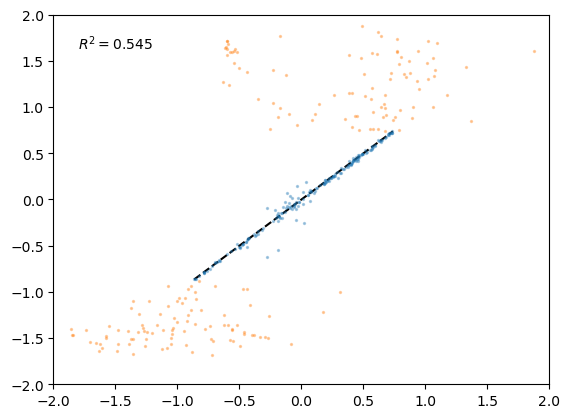

In [40]:
torch.manual_seed(0)
input_dim = X_train.shape[1]
hidden_dim = (16,16,16)
output_dim = 1

X_train = torch.Tensor(X_train)
y_train_st = torch.Tensor(y_train[:,0].reshape(-1,1))
model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = MultiTaskMSELoss()
trainer = base_trainer(model, optimizer)
lite_model, best_model_wts = trainer(X_train, y_train_st, criterion)

torch.save(best_model_wts,os.path.join(os.path.join(models_saveloc,mode,'STL0.pt')))

st_model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim)
st_model.load_state_dict(best_model_wts)
# best_model = lite_model
st_model.eval()
with torch.no_grad():
        out_test = st_model(torch.Tensor(X_test))
        out_train = st_model(torch.Tensor(X_train))


fig,ax = plt.subplots()
min_max = [op(y_train[:, 0]) for op in (np.nanmin, np.nanmax)]
ax.plot(min_max, min_max, 'k--', zorder=0)

is_finite = np.isfinite(y_test[:, 0])
r2_test = r2_score(y_test[:, 0], out_test)
ax.scatter(out_train, y_train[:, 0], s=2, alpha=0.33)
ax.scatter(out_test, y_test[:, 0], s=2, alpha=0.33)
ax.text(0.05, 0.95, f'$R^2 = {r2_test:.3f}$', transform=ax.transAxes, ha='left', va='top')
# ax.set_ylim(y_test[:,0].min(),y_test[:,0].max())
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2) 


In [42]:
st_model.eval()
with torch.no_grad():
        out_test = st_model(torch.Tensor(X_test))
        out_train = st_model(torch.Tensor(X_train))
mean_squared_error(y_test[:, 0], out_test)


0.8197065

### MTL0

Epoch 1000, MSE: 0.1213, L0R: 870.39
Epoch 2000, MSE: 0.1140, L0R: 817.81
Epoch 3000, MSE: 0.1059, L0R: 781.45
Epoch 4000, MSE: 0.1026, L0R: 761.61
Epoch 5000, MSE: 0.1021, L0R: 750.37
Epoch 6000, MSE: 0.1007, L0R: 744.40
Epoch 7000, MSE: 0.0986, L0R: 741.44
Epoch 8000, MSE: 0.0970, L0R: 740.08
Epoch 9000, MSE: 0.0961, L0R: 739.81
Epoch 10000, MSE: 0.0937, L0R: 740.36
Epoch 11000, MSE: 0.0934, L0R: 741.15
Epoch 12000, MSE: 0.0899, L0R: 741.85
Epoch 13000, MSE: 0.0913, L0R: 742.82
Epoch 14000, MSE: 0.0896, L0R: 743.74
Epoch 15000, MSE: 0.0930, L0R: 744.73
Epoch 16000, MSE: 0.0899, L0R: 745.58
Epoch 17000, MSE: 0.0833, L0R: 746.69
Epoch 18000, MSE: 0.0773, L0R: 747.23
Epoch 19000, MSE: 0.0775, L0R: 747.57
Epoch 20000, MSE: 0.0746, L0R: 748.15
Epoch 21000, MSE: 0.0739, L0R: 748.52
Epoch 22000, MSE: 0.0752, L0R: 748.57
Epoch 23000, MSE: 0.0699, L0R: 748.14
Epoch 24000, MSE: 0.0631, L0R: 747.55
Epoch 25000, MSE: 0.0587, L0R: 746.49
Epoch 26000, MSE: 0.0562, L0R: 745.39
Epoch 27000, MSE: 0.0

(-2.0, 2.0)

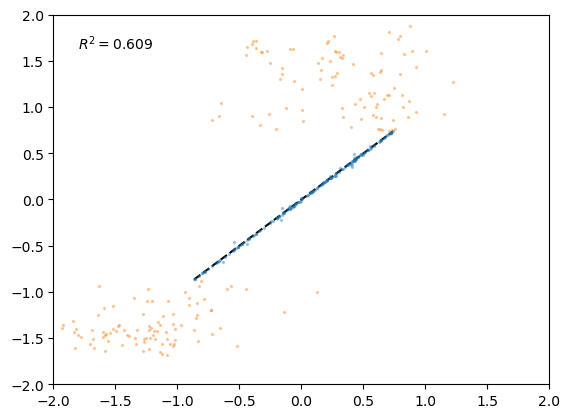

In [41]:
torch.manual_seed(0)
input_dim = X_train.shape[1]
hidden_dim = (16,16,16)
output_dim = y_train.shape[1]
criterion = MultiTaskMSELoss()

y_train_mt = torch.Tensor(y_train)
model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
pcgrad_mtl = wPCGrad(model, output_dim, optimizer, criterion, lambda_reg=1e-5)
dtp = DynamicTaskPrioritization(output_dim, gamma=2)
task_priority = [0]

trainer = wPCGrad_DTP_trainer(pcgrad_mtl, dtp, task_priority)
lite_model, best_model_wts = trainer(X_train, y_train_mt, criterion)
torch.save(best_model_wts,os.path.join(os.path.join(models_saveloc,mode,'MTL0.pt')))

mt_model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim)
mt_model.load_state_dict(best_model_wts)
# best_model = lite_model
mt_model.eval()
with torch.no_grad():
    out_test = mt_model(torch.Tensor(X_test))
    out_train = mt_model(torch.Tensor(X_train))


fig,ax = plt.subplots()
min_max = [op(y_train[:, 0]) for op in (np.nanmin, np.nanmax)]
ax.plot(min_max, min_max, 'k--', zorder=0)

is_finite = np.isfinite(y_test[:, 0])
r2_test = r2_score(y_test[:, 0], out_test[:,0])
ax.scatter(out_train[:,0], y_train[:, 0], s=2, alpha=0.33)
ax.scatter(out_test[:,0], y_test[:, 0], s=2, alpha=0.33)
ax.text(0.05, 0.95, f'$R^2 = {r2_test:.3f}$', transform=ax.transAxes, ha='left', va='top')
# ax.set_ylim(y_test[:,0].min(),y_test[:,0].max())
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2) 

# Interpolation

Epoch 1000, MSE: 0.1503, L0R: 788.81
Epoch 2000, MSE: 0.2340, L0R: 701.29
Epoch 3000, MSE: 0.1361, L0R: 646.78
Epoch 4000, MSE: 0.1609, L0R: 620.16
Epoch 5000, MSE: 0.1443, L0R: 607.14
Epoch 6000, MSE: 0.1907, L0R: 600.20
Epoch 7000, MSE: 0.1028, L0R: 596.15
Epoch 8000, MSE: 0.1155, L0R: 593.47
Epoch 9000, MSE: 0.0553, L0R: 591.56
Epoch 10000, MSE: 0.0535, L0R: 590.03
Epoch 11000, MSE: 0.0566, L0R: 588.45
Epoch 12000, MSE: 0.1070, L0R: 587.09
Epoch 13000, MSE: 0.0736, L0R: 586.37
Epoch 14000, MSE: 0.0619, L0R: 586.12
Epoch 15000, MSE: 0.0531, L0R: 585.87
Epoch 16000, MSE: 0.0485, L0R: 585.46
Epoch 17000, MSE: 0.0438, L0R: 584.97
Epoch 18000, MSE: 0.0387, L0R: 584.17
Epoch 19000, MSE: 0.0835, L0R: 582.72
Epoch 20000, MSE: 0.0383, L0R: 581.05
Epoch 21000, MSE: 0.0418, L0R: 579.24
Epoch 22000, MSE: 0.0325, L0R: 577.09
Epoch 23000, MSE: 0.0455, L0R: 574.58
Epoch 24000, MSE: 0.0380, L0R: 571.97
Epoch 25000, MSE: 0.0316, L0R: 569.37
Epoch 26000, MSE: 0.0324, L0R: 566.91
Epoch 27000, MSE: 0.0

(-2.0, 2.0)

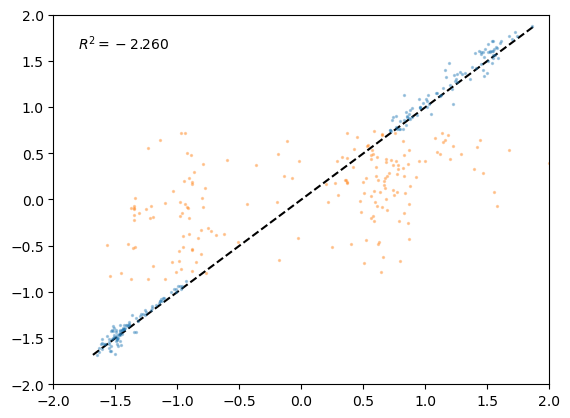

In [37]:
torch.manual_seed(0)
input_dim = X_train.shape[1]
hidden_dim = (16,16,16)
output_dim = 1

X_train = torch.Tensor(X_train)
y_train_st = torch.Tensor(y_train[:,0].reshape(-1,1))
model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim) #, activation=nn.LeakyReLU()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = MultiTaskMSELoss()
trainer = base_trainer(model, optimizer)
lite_model, best_model_wts = trainer(X_train, y_train_st, criterion)

torch.save(best_model_wts,os.path.join(os.path.join(models_saveloc,mode,'STL0.pt')))

st_model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim) #, activation=nn.LeakyReLU()
st_model.load_state_dict(best_model_wts)
# best_model = lite_model
st_model.eval()
with torch.no_grad():
        out_test = st_model(torch.Tensor(X_test))
        out_train = st_model(torch.Tensor(X_train))


fig,ax = plt.subplots()
min_max = [op(y_train[:, 0]) for op in (np.nanmin, np.nanmax)]
ax.plot(min_max, min_max, 'k--', zorder=0)

is_finite = np.isfinite(y_test[:, 0])
r2_test = r2_score(y_test[:, 0], out_test)
ax.scatter(out_train, y_train[:, 0], s=2, alpha=0.33)
ax.scatter(out_test, y_test[:, 0], s=2, alpha=0.33)
ax.text(0.05, 0.95, f'$R^2 = {r2_test:.3f}$', transform=ax.transAxes, ha='left', va='top')
# ax.set_ylim(y_test[:,0].min(),y_test[:,0].max())
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2) 

Text(0, 0.5, 'Values')

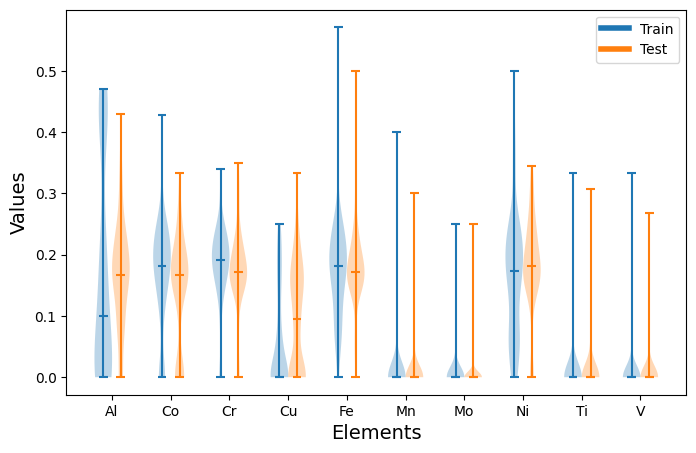

In [38]:
mode = 'interpolation'
# if not os.path.exists(os.path.join(models_saveloc,mode)):
#     os.makedirs(os.path.join(models_saveloc,mode))

missing, miss_idx, lo, hi = insert_missing_values(y_original, main_task, task_list, mode = mode)

X_train = comp_vec
y_train = missing
X_test = comp_vec[miss_idx[0]]
y_test = y_original[miss_idx[0]]

test_comps = X_train[~np.isfinite(y_train[:,0])]
train_comps = X_train[np.isfinite(y_train[:,0])]

fig,ax = plt.subplots(figsize = (8,5))

x_plot_train = np.arange(train_comps.shape[1])
x_plot_test = x_plot_train+0.3
ax.violinplot(train_comps.numpy(), positions = x_plot_train, widths=0.3,showmeans=False, showmedians=True)
ax.violinplot(test_comps.numpy(), positions = x_plot_test, widths= 0.3, showmeans=False, showmedians=True)
ax.set_xticks(x_plot_train + 0.15, order)

train_artist = plt.Line2D([0], [0], color='tab:blue', lw=4, label='Train')
test_artist = plt.Line2D([0], [0], color='tab:orange', lw=4, label='Test')

# Add legend
ax.legend(handles=[train_artist, test_artist])
# Add labels and title

ax.set_xlabel('Elements', fontsize = 14)
ax.set_ylabel('Values', fontsize = 14)

### RF

In [43]:
print(X_train.shape)
print(y_train.shape)

torch.Size([370, 10])
(370, 4)


(-2.0, 2.0)

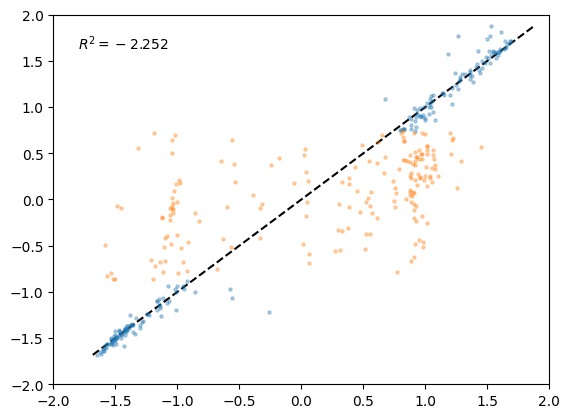

In [57]:
from sklearn import preprocessing

rf = RandomForestRegressor(random_state = 0)

# ADDING SCALERS
is_finite = np.argwhere(np.isfinite(y_train[:, 0])).flatten()
x_scaler = preprocessing.StandardScaler().fit(X_train.numpy()[is_finite])
y_scaler = preprocessing.StandardScaler().fit(y_train[is_finite][:, [0]])

_ = rf.fit(x_scaler.transform(X_train.numpy()[is_finite]),
           y_scaler.transform(y_train[is_finite][:, [0]]).flatten())

# onx = to_onnx(rf, X_train[:1].numpy().astype(np.float32), target_opset=12)
# with open(os.path.join(models_saveloc,mode,'RF.onnx'), "wb") as f:
#     f.write(onx.SerializeToString())

out_train = y_scaler.inverse_transform( rf.predict(x_scaler.transform(X_train.numpy())).reshape(-1, 1) )
out_test = y_scaler.inverse_transform( rf.predict(x_scaler.transform(X_test.numpy())).reshape(-1, 1) )

fig,ax = plt.subplots()
min_max = [op(y_train[:, 0]) for op in (np.nanmin, np.nanmax)]
ax.plot(min_max, min_max, 'k--', zorder=0)

is_finite = np.isfinite(y_test[:, 0])
r2_test = r2_score(y_test[:, 0], out_test)
ax.scatter(out_train, y_train[:, 0], s=5, alpha=0.33)
ax.scatter(out_test, y_test[:, 0], s=5, alpha=0.33)
ax.text(0.05, 0.95, f'$R^2 = {r2_test:.3f}$', transform=ax.transAxes, ha='left', va='top')
# ax.set_ylim(y_test[:,0].min(),y_test[:,0].max())
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2) 

### STL0

In [178]:
input_dim = X_train.shape[1]
hidden_dim = (16,16,16)
output_dim = 1

best_model_wts = torch.load('l0_saved_models/yang_dataset/interpolation/STL0.pt')

st_model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim) #, activation=nn.LeakyReLU()
st_model.load_state_dict(best_model_wts)
st_model.eval()
with torch.no_grad():
        out_test = st_model(torch.Tensor(X_test))
        out_train = st_model(torch.Tensor(X_train))

is_finite = np.argwhere(np.isfinite(y_train[:,0])).flatten()
print(r2_score(out_train[is_finite,0], y_train[is_finite,0] ))

is_finite = np.argwhere(np.isfinite(y_test[:,0])).flatten()
r2_score( y_test[:,0],out_test[:,0])

0.9962005941190895


/tmp/ipykernel_3982599/3710994113.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model_wts = torch.load('l0_saved_models/yang_dataset/interpolation/STL0.pt')


-2.260478801355963

### MTL0

Epoch 1000, MSE: 0.1657, L0R: 879.41
Epoch 2000, MSE: 0.1318, L0R: 819.90
Epoch 3000, MSE: 0.1369, L0R: 778.82
Epoch 4000, MSE: 0.1249, L0R: 755.46
Epoch 5000, MSE: 0.1570, L0R: 742.14
Epoch 6000, MSE: 0.1418, L0R: 734.19
Epoch 7000, MSE: 0.1277, L0R: 730.01
Epoch 8000, MSE: 0.1182, L0R: 728.18
Epoch 9000, MSE: 0.1039, L0R: 728.08
Epoch 10000, MSE: 0.0863, L0R: 728.64
Epoch 11000, MSE: 0.0844, L0R: 729.78
Epoch 12000, MSE: 0.0656, L0R: 731.18
Epoch 13000, MSE: 0.0660, L0R: 732.66
Epoch 14000, MSE: 0.0542, L0R: 734.15
Epoch 15000, MSE: 0.0589, L0R: 735.71
Epoch 16000, MSE: 0.0502, L0R: 737.12
Epoch 17000, MSE: 0.0457, L0R: 738.51
Epoch 18000, MSE: 0.0431, L0R: 739.62
Epoch 19000, MSE: 0.0406, L0R: 740.75
Epoch 20000, MSE: 0.0360, L0R: 741.77
Epoch 21000, MSE: 0.0344, L0R: 742.27
Epoch 22000, MSE: 0.0326, L0R: 742.75
Epoch 23000, MSE: 0.0322, L0R: 743.00
Epoch 24000, MSE: 0.0266, L0R: 743.06
Epoch 25000, MSE: 0.0240, L0R: 742.82
Epoch 26000, MSE: 0.0227, L0R: 742.10
Epoch 27000, MSE: 0.0

(-2.0, 2.0)

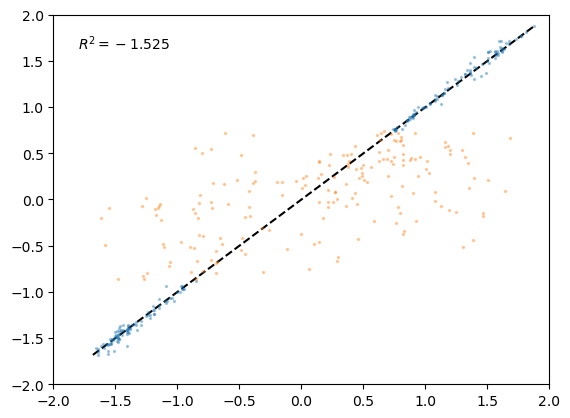

In [36]:
torch.manual_seed(0)
input_dim = X_train.shape[1]
hidden_dim = (16,16,16)
output_dim = y_train.shape[1]
criterion = MultiTaskMSELoss()

y_train_mt = torch.Tensor(y_train)
model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim) #, activation = nn.LeakyReLU()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
pcgrad_mtl = wPCGrad(model, output_dim, optimizer, criterion, lambda_reg=1e-5)
dtp = DynamicTaskPrioritization(output_dim, gamma=2)
task_priority = [0]

trainer = wPCGrad_DTP_trainer(pcgrad_mtl, dtp, task_priority)
lite_model, best_model_wts = trainer(X_train, y_train_mt, criterion, patience_interval = 1000)
torch.save(best_model_wts,os.path.join(os.path.join(models_saveloc,mode,'MTL0.pt')))

mt_model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim) #, activation=nn.LeakyReLU()
mt_model.load_state_dict(best_model_wts)
# best_model = lite_model
mt_model.eval()
with torch.no_grad():
    out_test = mt_model(torch.Tensor(X_test))
    out_train = mt_model(torch.Tensor(X_train))


fig,ax = plt.subplots()
min_max = [op(y_train[:, 0]) for op in (np.nanmin, np.nanmax)]
ax.plot(min_max, min_max, 'k--', zorder=0)

is_finite = np.isfinite(y_test[:, 0])
r2_test = r2_score(y_test[:, 0], out_test[:,0])
ax.scatter(out_train[:,0], y_train[:, 0], s=2, alpha=0.33)
ax.scatter(out_test[:,0], y_test[:, 0], s=2, alpha=0.33)
ax.text(0.05, 0.95, f'$R^2 = {r2_test:.3f}$', transform=ax.transAxes, ha='left', va='top')
# ax.set_ylim(y_test[:,0].min(),y_test[:,0].max())
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2) 